In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, completeness_score, homogeneity_score
from sklearn.mixture import GaussianMixture
import numpy as np
from sklearn.decomposition import PCA, TruncatedSVD
from iso3166 import countries

In [2]:
df = pd.read_csv('Country-data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
#df['country'] = df['country'].apply(countries)

In [5]:
df['life_expec'].max()

np.float64(82.8)

In [6]:
col_names = df.columns[1:].to_list()
col_names

['child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

In [7]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('country', axis=1))
df_scaled = pd.DataFrame(df_scaled, columns=col_names)
round(df_scaled.iloc[0][0], 2)

C:\Users\LNV\AppData\Local\Temp\ipykernel_19604\3724995615.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round(df_scaled.iloc[0][0], 2)


np.float64(1.29)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


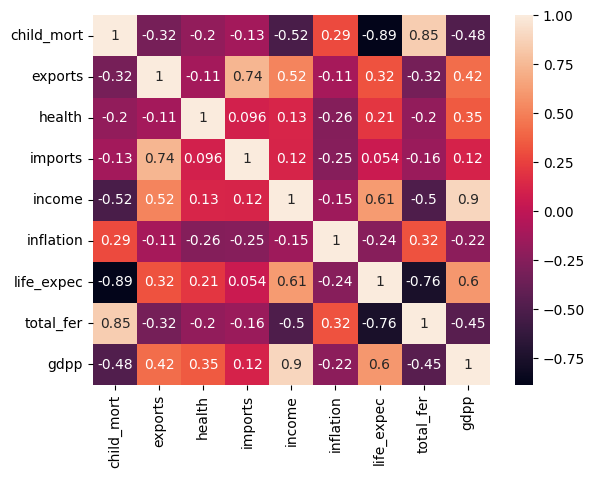

In [8]:
sns.heatmap(df_scaled.corr(), annot=True)
df_scaled.corr()

In [9]:
#определяем метод главных компонент с двумя компонентами
pca = PCA(n_components=0.90)
#обучаем алгоритм на наших данных
principalComponents = pca.fit_transform(df_scaled)
print(pca.n_components_)
print(round(pca.explained_variance_ratio_.max(), 2))

5
0.46


In [10]:
principalComponents = pd.DataFrame(principalComponents, columns=pca.get_feature_names_out())

<Axes: >

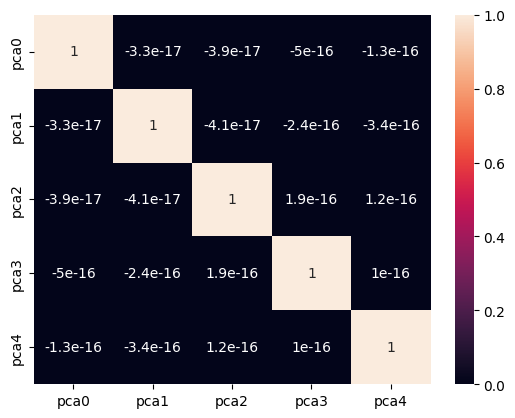

In [11]:
sns.heatmap(principalComponents.corr(), annot=True)

<Axes: xlabel='cluster', ylabel='silhouette'>

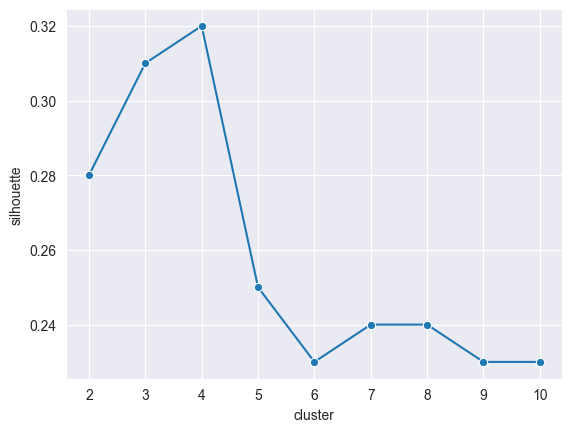

In [12]:
# напишем функцию, как и при подсчете метода локтя
def get_silhouette(cluster_num, x):
    k_means =  KMeans(n_clusters=cluster_num, random_state=1)#KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(x)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = silhouette_score(x, k_means.predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res1 = {"silhouette": [], "cluster": []}

for cluster_num in range(2, 11):
    silhouette_res1["silhouette"].append(round(get_silhouette(cluster_num, principalComponents), 2))
    silhouette_res1["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df1 = pd.DataFrame(silhouette_res1)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df1, x="cluster", y="silhouette", marker= "o")

In [13]:
cluster_num = silhouette_df1.sort_values(by='silhouette', ascending=False).head(1)#iloc[0,1]
cluster_num.iloc[0][-1]

C:\Users\LNV\AppData\Local\Temp\ipykernel_19604\2889942918.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cluster_num.iloc[0][-1]


np.float64(4.0)

In [14]:
#определяем алгоритм кластеризации
km = KMeans(n_clusters=int(cluster_num.iloc[0][-1]), random_state=1)
#обучаем его на наших данных
y_pred = km.fit_predict(principalComponents)
df.loc[:, 'label'] = y_pred

C:\Users\LNV\AppData\Local\Temp\ipykernel_19604\10404459.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  km = KMeans(n_clusters=int(cluster_num.iloc[0][-1]), random_state=1)


<Axes: xlabel='label', ylabel='child_mort'>

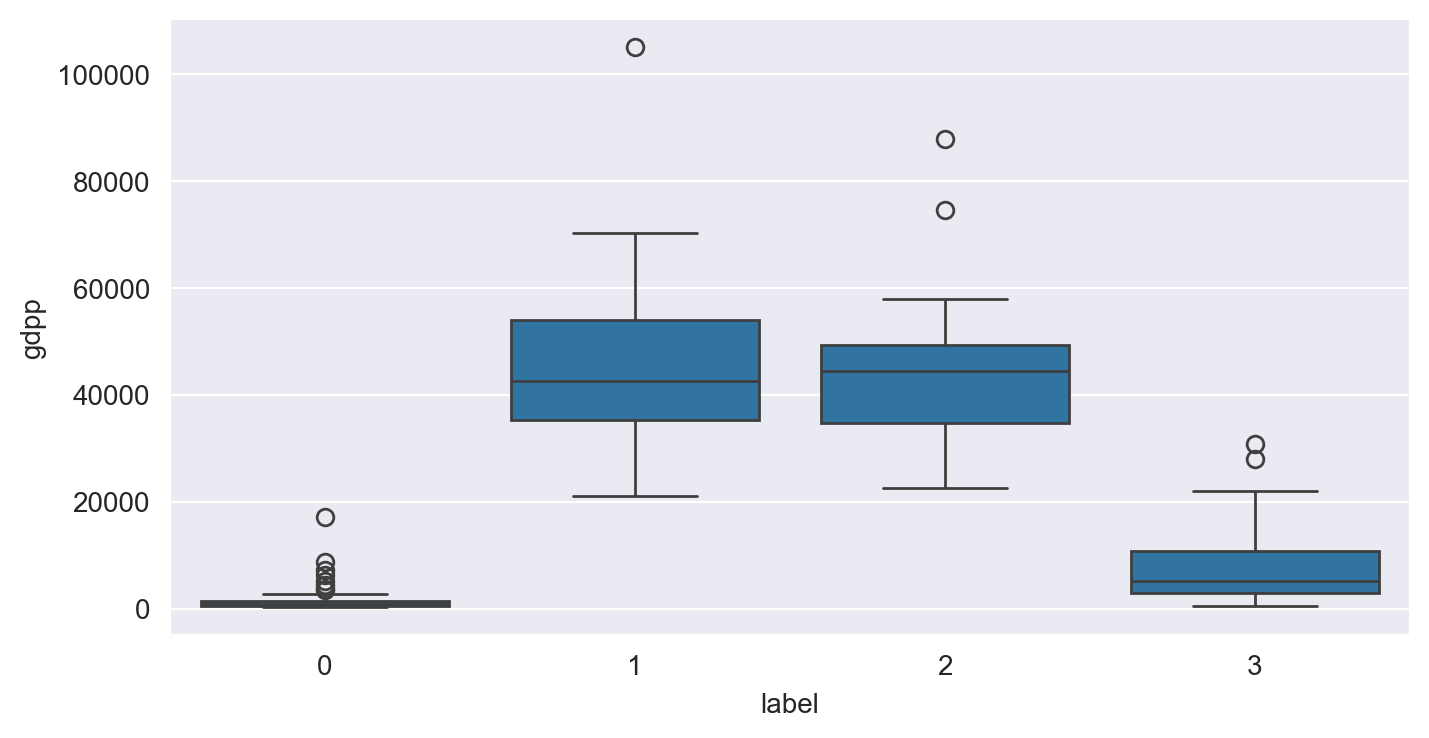

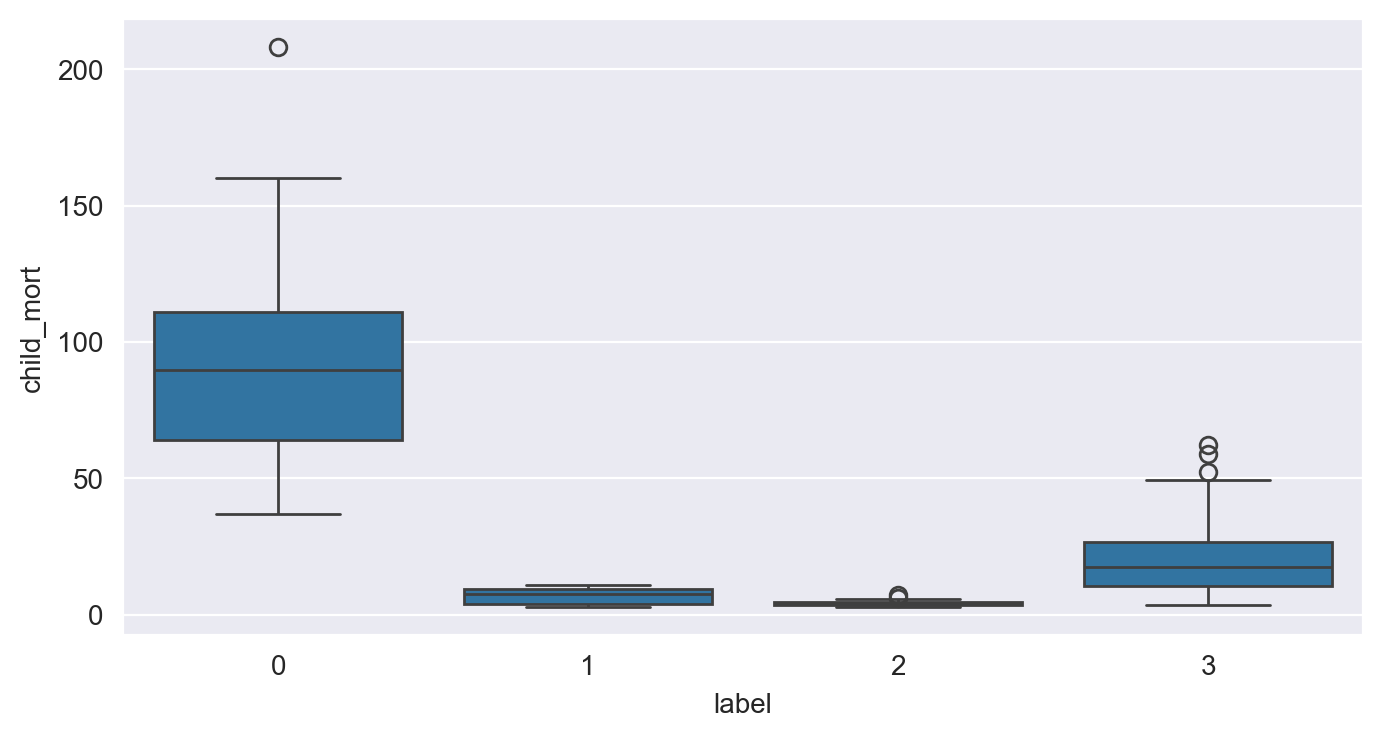

In [15]:
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='label', y='gdpp', data=df)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='label', y='child_mort', data=df)

In [16]:
df[df['label'] == 0].sort_values(by = 'life_expec', ascending=True).head(3)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,label
66,Haiti,208.0,15.3,6.91,64.7,1500,5.45,32.1,3.33,662,0
87,Lesotho,99.7,39.4,11.10,101.0,2380,4.15,46.5,3.30,1170,0
31,Central African Republic,149.0,11.8,3.98,26.5,888,2.01,47.5,5.21,446,0
